# Projet Time Series

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd

from tslearn.datasets import UCR_UEA_datasets

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Dataset

from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

import momentfm
from momentfm import MOMENTPipeline

In [6]:
ds = UCR_UEA_datasets()
X_train, y_train, X_test, y_test = ds.load_dataset("LSST")

In [7]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Data analysis

In [8]:
print(f"Format X_train : {X_train.shape}") # (nb_samples, nb_timestamps, nb_features)

print(f"Nombre de classes : {len(set(y_train))}")

Format X_train : (2459, 36, 6)
Nombre de classes : 14


In [9]:
print(X_train.shape,
y_train.shape,
X_test.shape,
y_train.shape)

(2459, 36, 6) (2459,) (2466, 36, 6) (2459,)


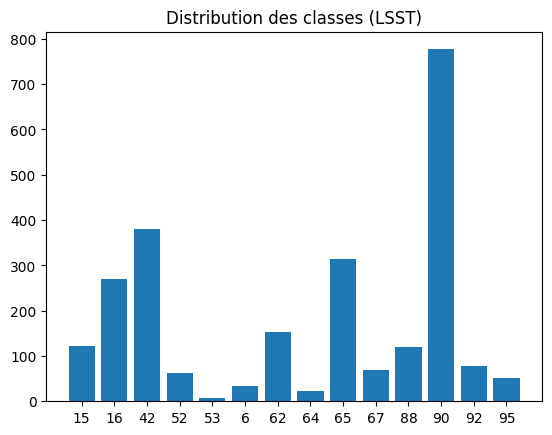

In [10]:
# Distribution des classes
classes, counts = np.unique(y_train, return_counts=True)
plt.bar(classes, counts)
plt.title("Distribution des classes (LSST)")
plt.show()

The classes are heavily imbalanced. We must pay attention to the F1-score when evaluating our models. We might also use the weight parameter in CrossEntropyLoss

In [11]:
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
weights_tensor = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

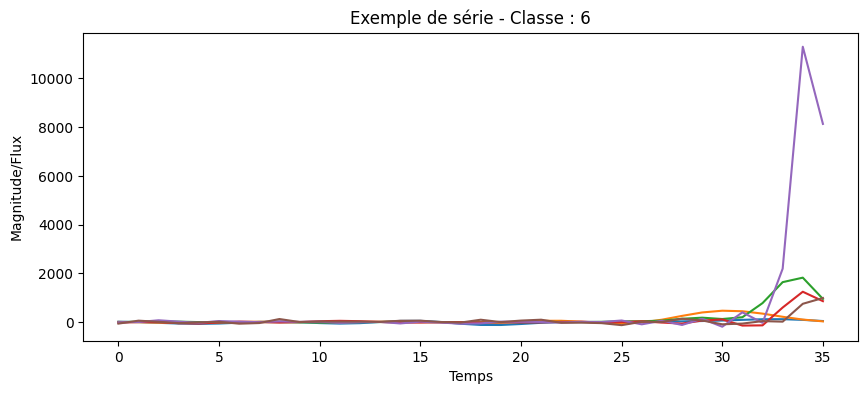

In [12]:
# Visualisation d'une série temporelle
# On affiche la première série (toutes ses features)
plt.figure(figsize=(10, 4))
plt.plot(X_train[0])
plt.title(f"Exemple de série - Classe : {y_train[0]}")
plt.xlabel("Temps")
plt.ylabel("Magnitude/Flux")
plt.show()

## Baseline

In [58]:
N_EPOCHS = 100
BATCH_SIZE = 32
LEARNING_RATE = 0.001

In [53]:
# Encodage des labels de 0 à C-1 (C le nb de classes)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)
num_classes = len(le.classes_)

# Conversion en Tensors et ajustement des dimensions (Batch, Channels, Length)
# Les données sont (N, 36, 6), PyTorch Conv1D attend (N, 6, 36)
X_train_t = torch.tensor(X_train, dtype=torch.float32).transpose(1, 2).to(DEVICE)
y_train_t = torch.tensor(y_train_encoded, dtype=torch.long).to(DEVICE)
X_test_t = torch.tensor(X_test, dtype=torch.float32).transpose(1, 2).to(DEVICE)
y_test_t = torch.tensor(y_test_encoded, dtype=torch.long).to(DEVICE)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE)



In [15]:
class TimeSeriesCNN(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


In [54]:
class TimeSeriesCNN(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.GELU(),
            
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.GELU(),

            nn.AdaptiveAvgPool1d(8),
            
            
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256), nn.GELU(),

            nn.AdaptiveAvgPool1d(1)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


In [55]:
model = TimeSeriesCNN(in_channels=X_train.shape[2], num_classes=num_classes).to(DEVICE)
criterion = nn.CrossEntropyLoss(weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [59]:
print(f"Début de l'entraînement pour {N_EPOCHS} époques...")

for epoch in range(N_EPOCHS):
    model.train()
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    # Évaluation
    model.eval()
    preds_list, targets_list = [], []
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            outputs = model(batch_X)
            preds = torch.argmax(outputs, dim=1)
            preds_list.extend(preds.cpu().numpy())
            targets_list.extend(batch_y.cpu().numpy())

    acc = accuracy_score(targets_list, preds_list)
    f1 = f1_score(targets_list, preds_list, average='macro')

    if (epoch + 1) % 5 == 0:
        print(f"Époque [{epoch+1}/{N_EPOCHS}] - Loss: {epoch_loss/len(train_loader):.4f} - Acc: {acc:.4f} - F1: {f1:.4f}")

Début de l'entraînement pour 100 époques...
Époque [5/100] - Loss: 1.0731 - Acc: 0.1671 - F1: 0.2856
Époque [10/100] - Loss: 1.2344 - Acc: 0.4019 - F1: 0.3273
Époque [15/100] - Loss: 1.0793 - Acc: 0.2011 - F1: 0.3265
Époque [20/100] - Loss: 0.9927 - Acc: 0.2478 - F1: 0.3865
Époque [25/100] - Loss: 1.0500 - Acc: 0.2721 - F1: 0.3771
Époque [30/100] - Loss: 0.9434 - Acc: 0.2056 - F1: 0.3020
Époque [35/100] - Loss: 0.9604 - Acc: 0.3496 - F1: 0.3614
Époque [40/100] - Loss: 0.9083 - Acc: 0.2040 - F1: 0.3401
Époque [45/100] - Loss: 0.9584 - Acc: 0.2433 - F1: 0.3540
Époque [50/100] - Loss: 0.8903 - Acc: 0.2676 - F1: 0.3811
Époque [55/100] - Loss: 0.9070 - Acc: 0.3151 - F1: 0.3580
Époque [60/100] - Loss: 0.8167 - Acc: 0.2068 - F1: 0.3223
Époque [65/100] - Loss: 1.2321 - Acc: 0.2048 - F1: 0.2979
Époque [70/100] - Loss: 0.8066 - Acc: 0.2068 - F1: 0.3266
Époque [75/100] - Loss: 0.7726 - Acc: 0.3378 - F1: 0.3812
Époque [80/100] - Loss: 0.7426 - Acc: 0.3171 - F1: 0.3512
Époque [85/100] - Loss: 0.729

## Setting 1 : Adapt a foundation model

In [30]:
def get_moment_model(model_id, num_classes, freeze_encoder=True):
    model = MOMENTPipeline.from_pretrained(
        model_id, 
        model_kwargs={
            "task_name": "embedding", 
            "n_channels": 6, 
            "seq_len": 512, 
            "freeze_encoder": freeze_encoder
        }
    ).to(DEVICE)

    # ACCÈS CORRIGÉ : On passe par .model.config
    hidden_dim = model.config.d_model 
    classifier = nn.Linear(hidden_dim, num_classes).to(DEVICE)
    
    return model, classifier

In [31]:
def train_and_eval_epoch(model, classifier, dataloader, optimizer, criterion, freeze_encoder, is_training=True):
    if is_training:
        model.train() if not freeze_encoder else model.eval()
        classifier.train()
    else:
        model.eval()
        classifier.eval()

    total_loss = 0
    all_preds, all_targets = [], []

    # Use no_grad if we are in eval mode OR if we are in training but the encoder is frozen
    grad_env = torch.set_grad_enabled(is_training and (not freeze_encoder or classifier.training))
    
    with grad_env:
        for batch_X, batch_y in dataloader:
            batch_X, batch_y = batch_X.to(DEVICE), batch_y.to(DEVICE)
            
            if batch_X.shape[1] == 36: batch_X = batch_X.transpose(1, 2)
            batch_X_pad = F.pad(batch_X, (0, 512 - batch_X.shape[-1]))

            if is_training: optimizer.zero_grad()
            
            outputs = model.embed(x_enc=batch_X_pad)
            embeddings = outputs.embeddings if hasattr(outputs, 'embeddings') else outputs
            pooled = embeddings.mean(dim=1) if embeddings.dim() == 3 else embeddings
            logits = classifier(pooled)
            
            loss = criterion(logits, batch_y)
            
            if is_training:
                loss.backward()
                optimizer.step()
            
            total_loss += loss.item()
            all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            all_targets.extend(batch_y.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    f1 = f1_score(all_targets, all_preds, average='macro')
    acc = accuracy_score(all_targets, all_preds)
    
    return avg_loss, acc, f1

In [32]:
def evaluate(model, classifier, dataloader):
    model.eval()
    classifier.eval()
    all_preds, all_targets = [], []
    
    with torch.no_grad():
        for batch_X, batch_y in dataloader:
            batch_X = batch_X.to(DEVICE)
            if batch_X.shape[1] == 36:
                batch_X = batch_X.transpose(1, 2)
            
            batch_X_pad = F.pad(batch_X, (0, 512 - batch_X.shape[-1]))
            
            # Pas de masque ici non plus
            outputs = model.embed(x_enc=batch_X_pad)
            embeddings = outputs.embeddings if hasattr(outputs, 'embeddings') else outputs
            pooled = embeddings.mean(dim=1) if embeddings.dim() == 3 else embeddings
            
            logits = classifier(pooled)
            preds = torch.argmax(logits, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(batch_y.cpu().numpy())
            
    return accuracy_score(all_targets, all_preds), f1_score(all_targets, all_preds, average='macro')

In [34]:
def run_experiment(model_id, freeze_encoder, epochs, lr):
    model, classifier = get_moment_model(model_id, num_classes, freeze_encoder)
    
    params = [
        {'params': model.parameters(), 'lr': lr}, 
        {'params': classifier.parameters(), 'lr': lr * 10}
    ]
    optimizer = torch.optim.AdamW(params)
    criterion = nn.CrossEntropyLoss(weight=weights_tensor)

    history = {
        'train_loss': [], 'test_loss': [],
        'train_f1': [], 'test_f1': []
    }

    for epoch in range(epochs): #
        train_loss, train_acc, train_f1 = train_and_eval_epoch(
            model, classifier, train_loader, optimizer, criterion, freeze_encoder, is_training=True
        )
        
        test_loss, test_acc, test_f1 = train_and_eval_epoch(
            model, classifier, test_loader, optimizer, criterion, freeze_encoder, is_training=False
        )
        
        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['train_f1'].append(train_f1)
        history['test_f1'].append(test_f1)
        
        print(f"Epoch [{epoch+1}/{epochs}] | Train F1: {train_f1:.4f} vs Test F1: {test_f1:.4f}")

    return model, classifier, history

In [45]:
def plot_confusion_matrix(model, classifier, dataloader, le):
    model.eval()
    classifier.eval()
    all_preds, all_targets = [], []
    
    with torch.no_grad():
        for batch_X, batch_y in dataloader:
            batch_X = batch_X.to(DEVICE)
            batch_X_pad = F.pad(batch_X, (0, 512 - batch_X.shape[-1]))
            outputs = model.embed(x_enc=batch_X_pad)
            embeddings = outputs.embeddings if hasattr(outputs, 'embeddings') else outputs
            pooled = embeddings.mean(dim=1) if embeddings.dim() == 3 else embeddings
            logits = classifier(pooled)
            all_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
            all_targets.extend(batch_y.cpu().numpy())
    
    cm = confusion_matrix(all_targets, all_preds)
    plt.figure(figsize=(12, 9))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Purples')
    plt.xlabel('Prédit')
    plt.ylabel('Réel')
    plt.title('Matrice de Confusion : MOMENT')
    plt.show()

#### Moment : Linear probing

In [36]:
print("Lancement du Linear Probing (MOMENT-small)...")
model_lp, classifier_lp, history_lp = run_experiment(model_id="AutonLab/MOMENT-1-small", freeze_encoder=True, epochs=20, lr=1e-3)

Lancement du Linear Probing (MOMENT-small)...
Epoch [1/20] | Train F1: 0.1034 vs Test F1: 0.1056
Epoch [2/20] | Train F1: 0.1563 vs Test F1: 0.1656
Epoch [3/20] | Train F1: 0.1776 vs Test F1: 0.1917
Epoch [4/20] | Train F1: 0.1985 vs Test F1: 0.2068
Epoch [5/20] | Train F1: 0.1955 vs Test F1: 0.2022
Epoch [6/20] | Train F1: 0.2172 vs Test F1: 0.1535
Epoch [7/20] | Train F1: 0.2322 vs Test F1: 0.2304
Epoch [8/20] | Train F1: 0.2243 vs Test F1: 0.1953
Epoch [9/20] | Train F1: 0.2322 vs Test F1: 0.2370
Epoch [10/20] | Train F1: 0.2473 vs Test F1: 0.2419
Epoch [11/20] | Train F1: 0.2369 vs Test F1: 0.2123
Epoch [12/20] | Train F1: 0.2396 vs Test F1: 0.1853
Epoch [13/20] | Train F1: 0.2473 vs Test F1: 0.2338
Epoch [14/20] | Train F1: 0.2432 vs Test F1: 0.2434
Epoch [15/20] | Train F1: 0.2532 vs Test F1: 0.2400
Epoch [16/20] | Train F1: 0.2595 vs Test F1: 0.2386
Epoch [17/20] | Train F1: 0.2642 vs Test F1: 0.2165
Epoch [18/20] | Train F1: 0.2779 vs Test F1: 0.2228
Epoch [19/20] | Train F1: 0

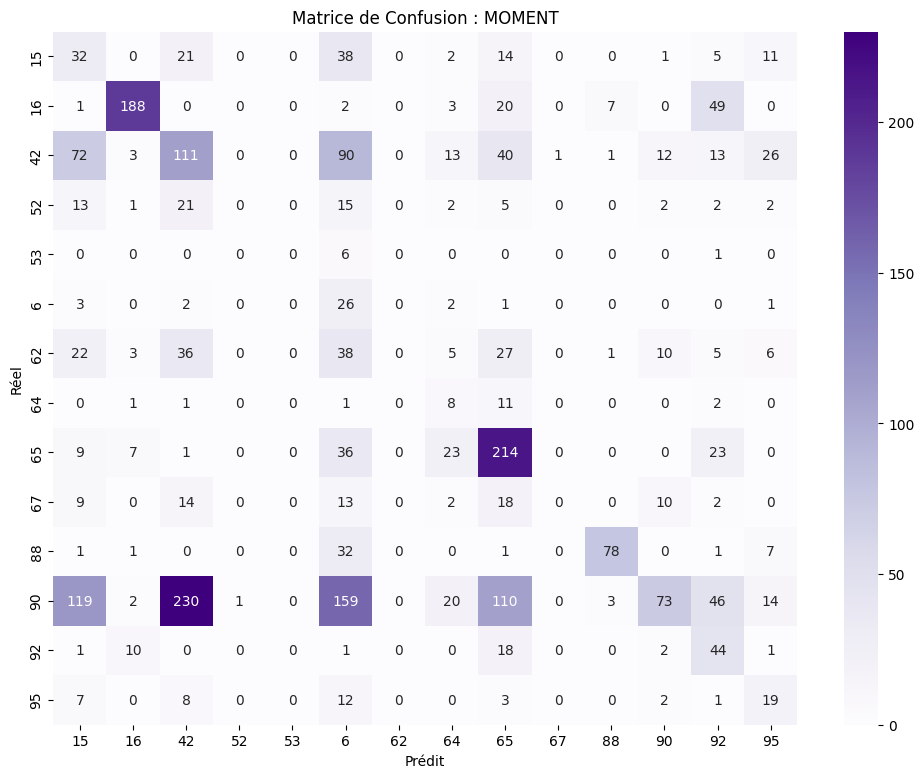

In [46]:
plot_confusion_matrix(model_lp, classifier_lp, test_loader, le)

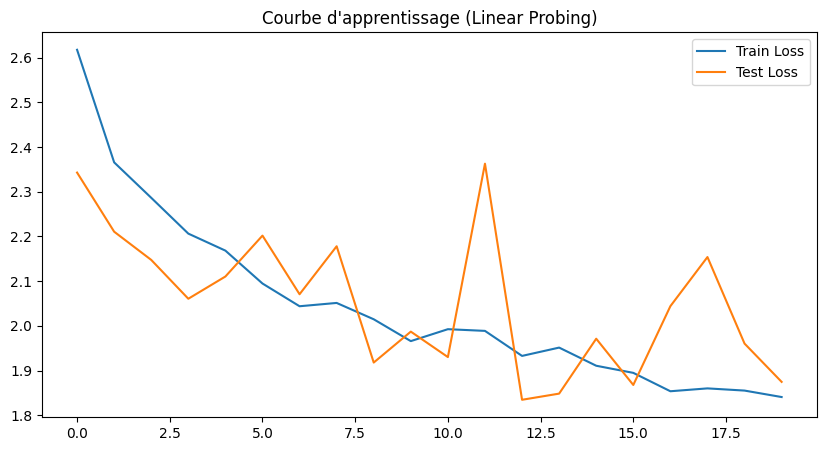

In [39]:
# quick verification of overfitting
plt.figure(figsize=(10, 5))
plt.plot(history_lp['train_loss'], label='Train Loss')
plt.plot(history_lp['test_loss'], label='Test Loss')
plt.title('Courbe d\'apprentissage (Linear Probing)')
plt.legend()
plt.show()

#### Moment : Fine-tuning

In [40]:
print("\nLancement du Fine-Tuning (MOMENT-small)...")
model_ft, classifier_ft, history_ft = run_experiment(model_id="AutonLab/MOMENT-1-small", freeze_encoder=False, epochs=10, lr=1e-5)


Lancement du Fine-Tuning (MOMENT-small)...
Epoch [1/10] | Train F1: 0.0303 vs Test F1: 0.0650
Epoch [2/10] | Train F1: 0.1421 vs Test F1: 0.2256
Epoch [3/10] | Train F1: 0.2179 vs Test F1: 0.2484
Epoch [4/10] | Train F1: 0.2531 vs Test F1: 0.2757
Epoch [5/10] | Train F1: 0.2889 vs Test F1: 0.2944
Epoch [6/10] | Train F1: 0.3014 vs Test F1: 0.2986
Epoch [7/10] | Train F1: 0.3101 vs Test F1: 0.3094
Epoch [8/10] | Train F1: 0.3458 vs Test F1: 0.3165
Epoch [9/10] | Train F1: 0.3362 vs Test F1: 0.3063
Epoch [10/10] | Train F1: 0.3676 vs Test F1: 0.3381


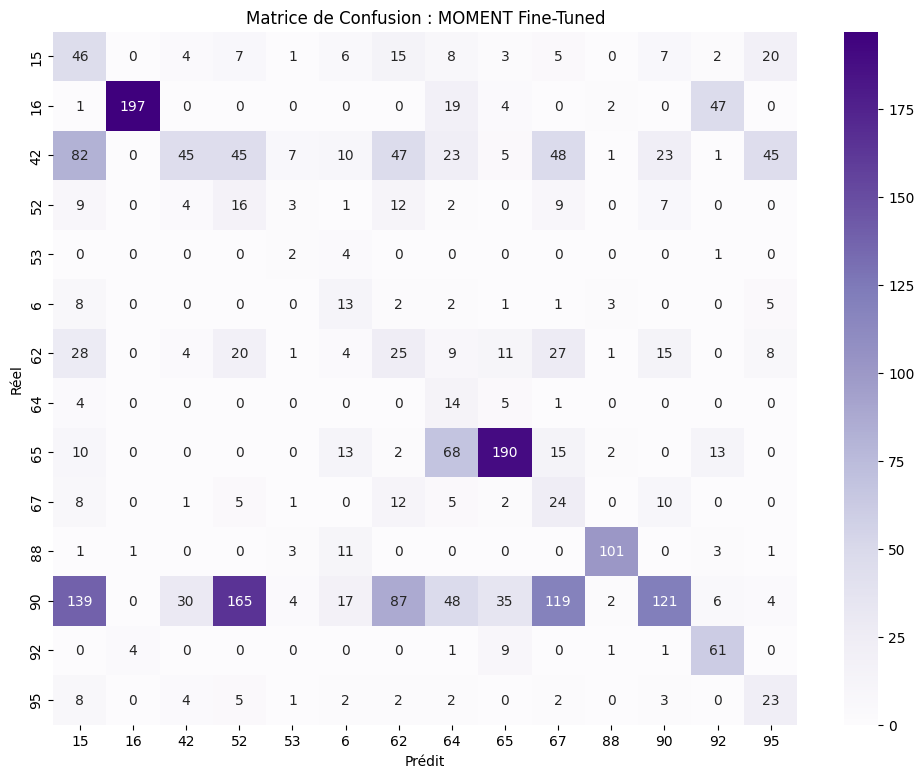

In [42]:
plot_confusion_matrix(model_ft, classifier_ft, test_loader, le)

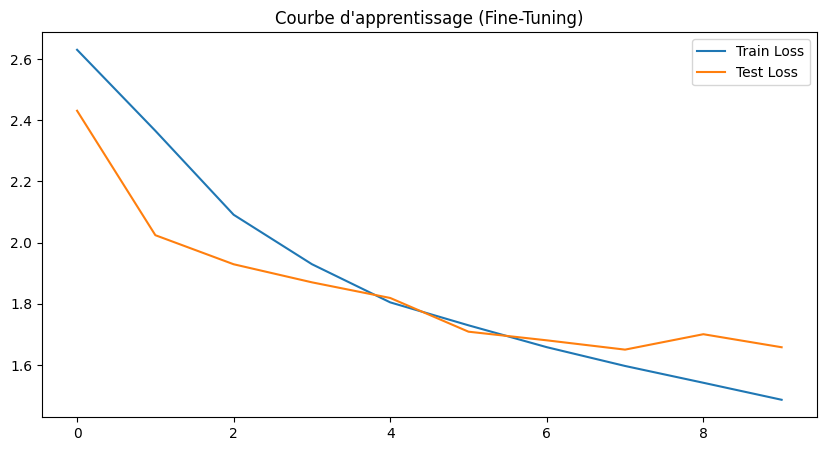

In [47]:
# quick verification of overfitting
plt.figure(figsize=(10, 5))
plt.plot(history_ft['train_loss'], label='Train Loss')
plt.plot(history_ft['test_loss'], label='Test Loss')
plt.title('Courbe d\'apprentissage (Fine-Tuning)')
plt.legend()
plt.show()

## Setting 2 : Pre-training on forecasting tasks

In [ ]:
# Téléchargement direct du dataset ETTh1 (7 variables)
url = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"
df = pd.read_csv(url)
data = df.drop(columns=['date']).values

# Normalisation simple
data = (data - data.mean(axis=0)) / data.std(axis=0)

#### Pre training :

In [ ]:
# Variable pour le nombre d'époques
N_EPOCHS_PRETRAIN = 40
BATCH_SIZE = 64
SEQ_LEN = 96  # Longueur de la fenêtre d'entrée
PRED_LEN = 1  # On prédit le point suivant
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
class InformerDataset(Dataset):
    def __init__(self, data, seq_len, pred_len):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.seq_len = seq_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_len

    def __getitem__(self, index):
        s_begin = index
        s_end = s_begin + self.seq_len
        r_begin = s_end
        r_end = r_begin + self.pred_len

        seq_x = self.data[s_begin:s_end]
        seq_y = self.data[r_begin:r_end]
        return seq_x, seq_y

train_ds = InformerDataset(data, SEQ_LEN, PRED_LEN)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

In [ ]:
class TransformerForecaster(nn.Module):
    def __init__(self, n_features=7, d_model=128, nhead=8, num_layers=3):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=512, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Tête de forecasting (prédit les variables pour le futur proche)
        self.forecasting_head = nn.Linear(d_model, n_features)

    def forward(self, x):
        # x: [Batch, Seq_Len, Features]
        x = self.input_proj(x)
        x = self.encoder(x)
        # On prédit à partir de la dernière représentation temporelle
        out = self.forecasting_head(x[:, -1, :])
        return out

In [ ]:
model = TransformerForecaster().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.MSELoss() # Utilisation de l'erreur quadratique pour le forecasting

In [ ]:
print(f"Début du pré-entraînement sur Informer (ETTh1) pour {N_EPOCHS_PRETRAIN} époques...") #

model.train()
for epoch in range(N_EPOCHS_PRETRAIN): #
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(batch_x)

        # batch_y est [Batch, Pred_Len, Features], on squeeze pour correspondre à outputs
        loss = criterion(outputs, batch_y.squeeze(1))

        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    print(f"Époque [{epoch+1}/{N_EPOCHS_PRETRAIN}] | Train MSE Loss: {epoch_loss/len(train_loader):.6f}")

# Sauvegarde de l'encodeur pour la phase suivante
torch.save(model.encoder.state_dict(), "pretrained_encoder.pt")
print("Pré-entraînement terminé. Encodeur sauvegardé.")

#### Fine tuning

In [ ]:
# --- 1. CONFIGURATION ---
# Utilisation d'une variable pour les époques
N_EPOCHS_ADAPT = 60
BATCH_SIZE = 32
LR = 1e-5 # On utilise un taux plus faible pour le fine-tuning
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# --- 2. CHARGEMENT DU DATASET LSST ---
# Utilisation de tslearn pour charger LSST
ds = UCR_UEA_datasets()
X_train, y_train, X_test, y_test = ds.load_dataset("LSST")

# Encodage des labels (pour éviter les erreurs d'index hors limites)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
num_classes = len(le.classes_)

# Préparation des DataLoaders
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train_enc, dtype=torch.long)),
    batch_size=BATCH_SIZE, shuffle=True
)
test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test_enc, dtype=torch.long)),
    batch_size=BATCH_SIZE
)

In [ ]:
# --- 3. ARCHITECTURE ADAPTÉE ---
class LSSTClassifier(nn.Module):
    def __init__(self, pretrained_encoder_path, d_model=128, num_classes=14):
        super().__init__()
        # On définit la même architecture d'encodeur que pour le pré-entraînement
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=8, dim_feedforward=512, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=3)

        # Chargement des poids pré-entraînés sur Informer
        self.encoder.load_state_dict(torch.load(pretrained_encoder_path))

        # Adaptation de l'entrée : LSST possède 6 variables
        self.input_proj = nn.Linear(6, d_model)

        # Tête de classification finale
        self.clf_head = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # x: [Batch, 36, 6]
        x = self.input_proj(x)
        x = self.encoder(x)
        # Global Average Pooling (moyenne sur la dimension temporelle)
        x = x.mean(dim=1)
        return self.clf_head(x)

In [ ]:
model = LSSTClassifier("pretrained_encoder.pt", num_classes=num_classes).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss(weights_tensor)

In [ ]:
# --- 4. BOUCLE DE FINE-TUNING ---
print(f"Début de l'adaptation sur LSST pour {N_EPOCHS_ADAPT} époques...")

for epoch in range(N_EPOCHS_ADAPT):
    model.train()
    total_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(DEVICE), batch_y.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Évaluation rapide sur le jeu de test [cite: 28]
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(DEVICE)
            outputs = model(batch_x)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(batch_y.numpy())

    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average='macro')

    print(f"Epoch [{epoch+1}/{N_EPOCHS_ADAPT}] | Loss: {total_loss/len(train_loader):.4f} | Acc: {acc:.4f} | F1: {f1:.4f}")